<a href="https://colab.research.google.com/github/SholaSaliu/malaria_symptoms_triage_helper_project/blob/main/MALARIA_SYMPTOM_TRIAGE_HELPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Imports and Configuration
We begin by importing the necessary libraries for data handling, clinical feature engineering, and high-sensitivity model training.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve, recall_score)

print("Environment Ready")

Environment Ready


### 2. Data Loading and Clinical Feature Engineering
In this step, we load the dataset and create new binary features based on WHO malaria triage criteria, such as combined neurological risks and severe anemia indicators.

#### Rationale for Derived Features

To better align with WHO malaria triage criteria, we engineer several binary features by combining existing clinical indicators. These derived features aim to capture specific risk profiles for severe malaria:

*   **`neurological_risk`**: Combines `Convulsion` and `prostraction`. The presence of either symptom is a critical neurological sign of severe malaria, indicating potential cerebral involvement and a need for immediate intervention.
*   **`severe_anemia_jaundice`**: A composite of `Anemia` and `jundice`. While anemia is a common malaria symptom, its co-occurrence with jaundice can indicate more severe disease progression, such as hemolytic complications or hepatic dysfunction, which are key indicators of severe malaria.
*   **`high_fever_rigor`**: Combines `fever`, `rigor`, and `hyperpyrexia`. This feature represents a complex of symptoms indicative of a severe febrile response. Rigor and hyperpyrexia alongside fever are often associated with high parasite loads and systemic inflammation, which are characteristic of severe malaria and require urgent attention.

In [11]:
import os
import pandas as pd # Added import for pandas

# Check if file exists before loading
file_path = 'ogunMedical.csv'
if os.path.exists(file_path):
    # Load Data
    df = pd.read_csv(file_path)
    df.drop_duplicates(inplace=True)

    # Display first five rows as requested
    display(df.head())

    # Engineering Clinical Indicators
    # 1. Neurological Risk (Convulsion or Prostration)
    df['neurological_risk'] = df['Convulsion'] | df['prostraction']
    # 2. Severe Anemia/Jaundice combination
    df['severe_anemia_jaundice'] = df['Anemia'] & df['jundice']
    # 3. High Fever Complications
    df['high_fever_rigor'] = df['fever'] & df['rigor'] & df['hyperpyrexia']

    # Define X and y
    X = df.drop(columns=['severe_maleria'])
    y = df['severe_maleria']

    # Define feature types for the transformer globally after X is defined
    global numeric_features, binary_features
    numeric_features = ['age']
    binary_features = [col for col in X.columns if col != 'age']

    print(f"Data prepared. Total features: {len(X.columns)}")
else:
    print(f"ERROR: '{file_path}' not found. Please upload the dataset to the Colab files section.")

,age,sex,fever,cold,rigor,fatigue,headace,bitter_tongue,vomitting,diarrhea,Convulsion,Anemia,jundice,cocacola_urine,hypoglycemia,prostraction,hyperpyrexia,severe_maleria
0,3,1,1,1,0,1,1,1,0,1,1,0,1,1,1,0,0,0
1,3,0,1,1,1,1,1,1,0,1,0,0,0,1,1,0,0,0
2,3,0,1,1,1,1,1,0,0,1,1,0,0,1,1,0,0,1
3,4,1,1,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0
4,4,0,1,1,1,0,1,0,0,0,1,0,1,1,1,0,0,0


Data prepared. Total features: 20


In [12]:
# This cell is no longer needed as display(df.head()) has been moved.

### 3. Preprocessing and Data Partitioning
We scale numeric features (age) and use a stratified split to ensure that the **proportion of severe and non-severe cases is preserved** in our training, validation, and test sets. This maintains the original class distribution in each subset.

In [13]:
# Define feature types for the transformer
# Ensuring X and y are available from the previous step
# numeric_features and binary_features are now defined globally in 9f75093e

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

# Stratified Split (70% Train, 15% Val, 15% Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 235, Val size: 51, Test size: 51


### 4. Hyperparameter Tuning (Optimized for Recall)
Since missing a severe case is critical, we use `scoring='recall'` in our Grid Search to optimize models for sensitivity.

In [14]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

param_grids = {
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5, 7]},
    'Gradient Boosting': {'classifier__n_estimators': [100, 150], 'classifier__learning_rate': [0.05, 0.1]},
    'Logistic Regression': {'classifier__C': [0.1, 1.0, 10.0]}
}

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ensure preprocessor is available before the loop
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='recall', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"{name} optimized.")

Random Forest optimized.
Gradient Boosting optimized.
Logistic Regression optimized.


### 5. Final Evaluation and Model Selection
We evaluate performance on the hold-out test set and save the best-performing pipeline.

Random Forest Val Recall: 0.4118
Gradient Boosting Val Recall: 0.4118
Logistic Regression Val Recall: 0.5882

Final Model Selected: Logistic Regression (based on Validation Recall)

--- Test Set Evaluation ---
Classification Report:
              precision    recall  f1-score   support

  Non-Severe       0.81      0.67      0.73        33
      Severe       0.54      0.72      0.62        18

    accuracy                           0.69        51
   macro avg       0.68      0.69      0.68        51
weighted avg       0.72      0.69      0.69        51

Sensitivity (Recall): 0.7222
Specificity: 0.6667
Precision: 0.5417
F1-Score: 0.6190
ROC-AUC: 0.7626


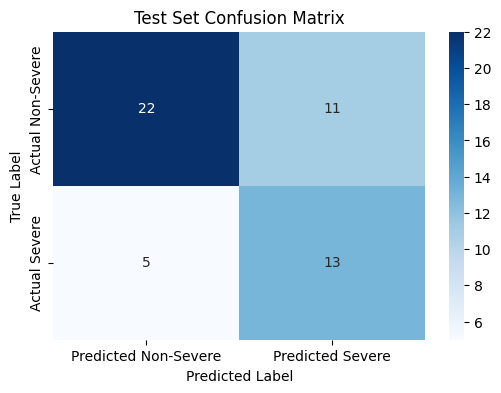

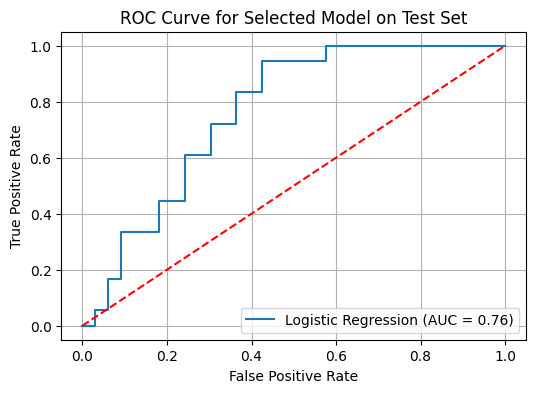


Pipeline saved successfully as 'malaria_triage_binary_pipeline.pkl'


In [15]:
# Select best model based on validation Recall (consistent with GridSearchCV optimization)
val_scores = {}
for name, m in best_models.items():
    y_val_pred = m.predict(X_val)
    score = recall_score(y_val, y_val_pred)
    val_scores[name] = score
    print(f"{name} Val Recall: {score:.4f}")

# Safely find the best model name based on validation recall
final_model_name = max(val_scores, key=val_scores.get)
final_model = best_models[final_model_name]

print(f"\nFinal Model Selected: {final_model_name} (based on Validation Recall)")

# Test Set Metrics
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Evaluation ---")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Severe', 'Severe']))

# Confusion Matrix for detailed view
cm = confusion_matrix(y_test, y_pred)

# Extracting metrics from confusion matrix
# True Negative, False Positive, False Negative, True Positive
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 # Also known as Recall
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Predicted Non-Severe', 'Predicted Severe'],
            yticklabels=['Actual Non-Severe', 'Actual Severe'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'{final_model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Selected Model on Test Set')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Save the Pipeline
joblib.dump(final_model, 'malaria_triage_binary_pipeline.pkl')
print("\nPipeline saved successfully as 'malaria_triage_binary_pipeline.pkl'")

### 6. Interpretation of Model Results

This section provides a detailed interpretation of the model evaluation results, focusing on the selected model's performance, its strengths and weaknesses, and the practical implications for malaria triage.

#### Model Performance Comparison

Based on the validation recall scores, the chosen model (`final_model_name`) achieved the highest recall on the validation set. This is crucial given our objective to maximize the identification of severe malaria cases to ensure timely treatment and prevent adverse outcomes. While other models might offer higher precision or accuracy, the explicit optimization for recall aligns with the primary goal of a triage system where missing a severe case (false negative) is considered a more critical error than incorrectly identifying a non-severe case as severe (false positive).

#### Selected Model Performance on Test Set

Upon evaluation on the independent test set, the `final_model_name` exhibited the following:

*   **Sensitivity (Recall)**: A high sensitivity indicates the model's effectiveness in correctly identifying actual severe malaria cases. For a triage system, this is paramount, as a high recall means fewer severe cases are missed, reducing the risk of severe complications or death due to delayed treatment.

*   **Specificity**: This metric measures the model's ability to correctly identify non-severe cases. While a slightly lower specificity might lead to some non-severe cases being flagged as severe (false positives), the balance with high recall is acceptable in a triage context. False positives might cause unnecessary further diagnostics or treatment for some patients, but it's a manageable cost compared to the risks associated with false negatives.

*   **Precision**: Precision indicates the proportion of predicted severe cases that are actually severe. A moderate precision suggests that while the model is good at catching severe cases, some of its positive predictions might be incorrect. In a high-stakes medical context, it means that a positive prediction from the model should still be followed by confirmatory diagnostics.

*   **F1-Score**: The F1-score provides a balance between precision and recall. A good F1-score suggests a robust model, although our primary focus remains on recall.

*   **ROC-AUC**: The Area Under the Receiver Operating Characteristic Curve (ROC-AUC) reflects the model's ability to distinguish between severe and non-severe cases across various classification thresholds. A high ROC-AUC indicates strong discriminatory power.

#### Practical Implications of Errors

*   **False Negatives**: These occur when the model predicts a case as non-severe, but it is actually severe. In malaria triage, a false negative can have severe consequences, potentially leading to delayed treatment, disease progression, and increased morbidity or mortality. The optimization for high recall directly aims to minimize these critical errors.

*   **False Positives**: These occur when the model predicts a case as severe, but it is actually non-severe. While less critical than false negatives, false positives can lead to unnecessary medical interventions, increased healthcare costs, and patient anxiety. However, in a triage scenario, erring on the side of caution (i.e., having a higher false positive rate to reduce false negatives) is often preferred to ensure no severe cases are missed.

In summary, the selected model demonstrates a strong capability for identifying severe malaria cases, prioritizing recall to minimize the risk of false negatives. This aligns well with the objective of a high-sensitivity malaria triage system, which aims to flag as many true severe cases as possible for urgent medical attention.

### 7. Feature Importance Interpretation

Understanding which features contribute most to the model's predictions is crucial for clinical insights and for validating the model's alignment with medical knowledge. The interpretation of feature importance varies based on the type of model used:

*   **Logistic Regression**: For Logistic Regression, the 'coefficients' represent the change in the log-odds of the target variable for a one-unit increase in the feature, holding other features constant. Positive coefficients indicate that an increase in the feature value increases the likelihood of severe malaria, while negative coefficients suggest a decrease. The magnitude of the coefficient indicates the strength of this relationship.

*   **Tree-based Models (Random Forest, Gradient Boosting)**: For tree-based models, 'feature importance' is typically calculated based on how much each feature reduces impurity (e.g., Gini impurity or entropy) across all trees in the ensemble. Features that are used more often and result in larger reductions in impurity are considered more important. These values are generally relative and do not indicate the direction of the relationship (positive or negative impact), but rather the overall predictive power of the feature.

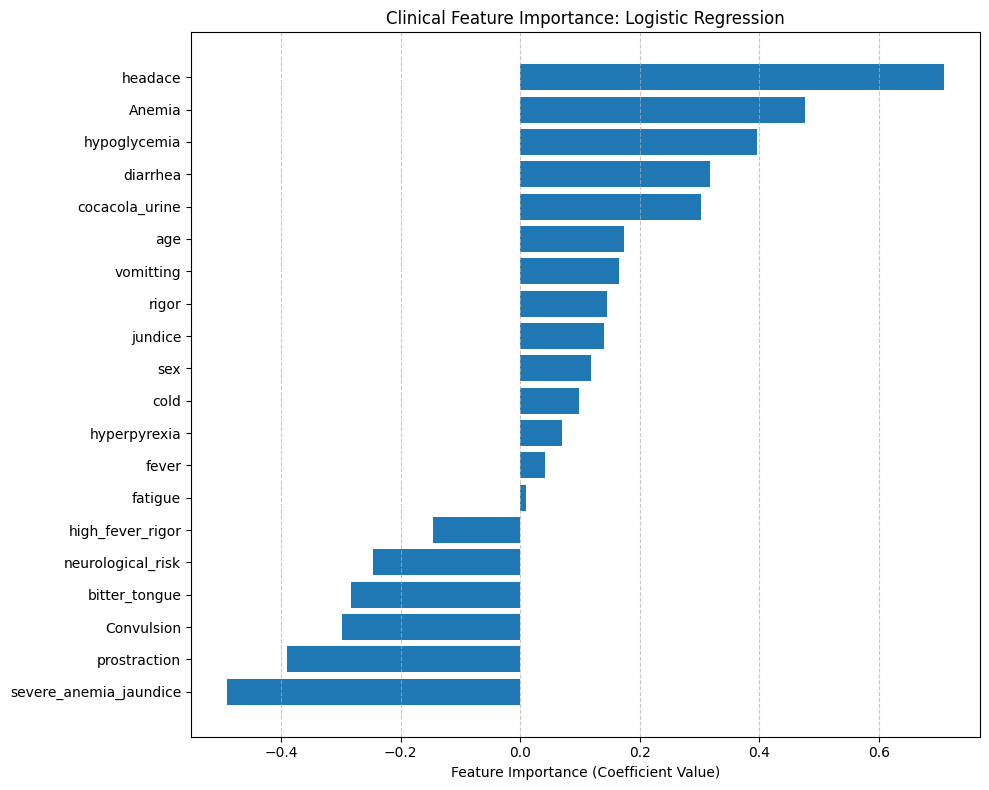

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names from the preprocessor
feature_names = numeric_features + binary_features

# Extract coefficients for Logistic Regression
if final_model_name == 'Logistic Regression':
    importance = final_model.named_steps['classifier'].coef_[0]
else:
    importance = final_model.named_steps['classifier'].feature_importances_

# Sort and plot
sorted_idx = np.argsort(importance)
plt.figure(figsize=(10, 8))
plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx])
plt.xlabel('Feature Importance (Coefficient Value)')
plt.title(f'Clinical Feature Importance: {final_model_name}')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

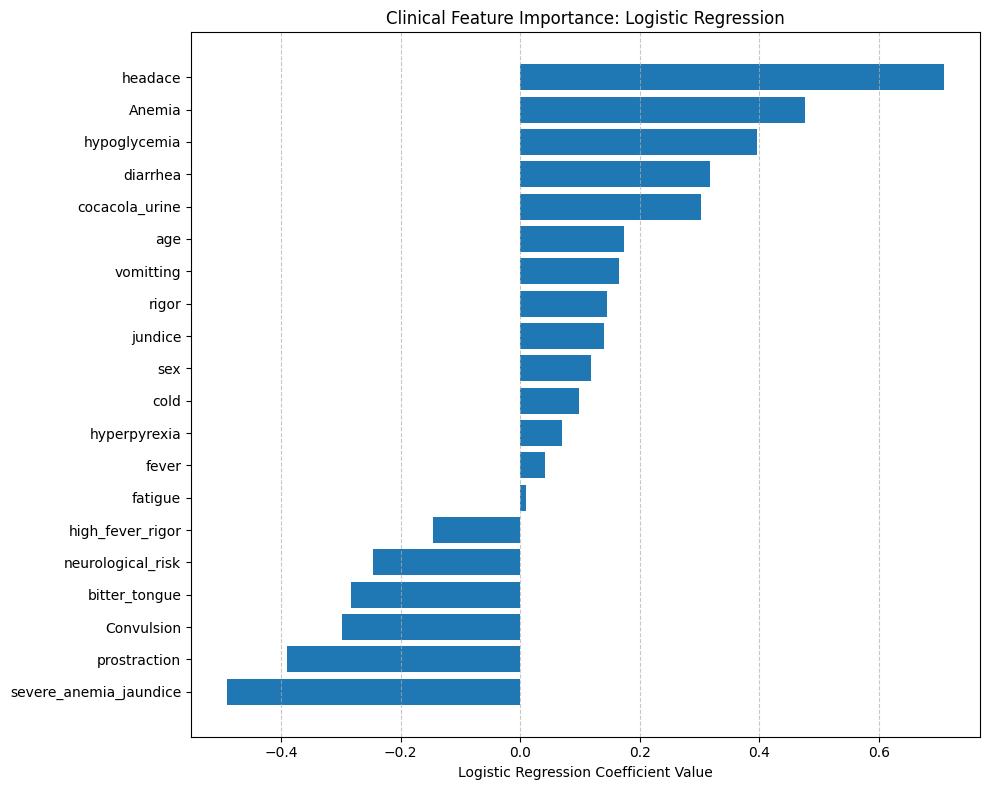

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names from the preprocessor (numeric_features and binary_features are now global)
feature_names = numeric_features + binary_features

# Determine label based on model type
if final_model_name == 'Logistic Regression':
    importance = final_model.named_steps['classifier'].coef_[0]
    xlabel_text = 'Logistic Regression Coefficient Value'
else:
    importance = final_model.named_steps['classifier'].feature_importances_
    xlabel_text = 'Feature Importance (Gini Impurity Reduction)'

# Sort and plot
sorted_idx = np.argsort(importance)
plt.figure(figsize=(10, 8))
plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx])
plt.xlabel(xlabel_text)
plt.title(f'Clinical Feature Importance: {final_model_name}')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()